# 01- Data exploration

**Goal :** Understand what audio looks like. Load a clip, plot the waveform, visually identify silence gaps and speech regions.

**What this notebook covers:**
- Load audio with librosa
- Plot waveform
- Visualise amplitude over time
- Manually spot where silence gaps are

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print('librosa:', librosa.__version__)

librosa: 0.11.0


## Load a sample audio clip

In [3]:
y, sr = librosa.load(librosa.ex('trumpet'))

print(f'Duration  : {len(y)/sr:.2f} seconds')
print(f'Sample rate: {sr} Hz')
print(f'Samples   : {len(y)}')

Duration  : 5.33 seconds
Sample rate: 22050 Hz
Samples   : 117601


## Plot the waveform

The waveform shows amplitude (loudness) over time. Speech shows up as bursts of energy; silence shows up as near-zero amplitude.

This is what VAD operates on — it looks at these energy bursts and labels them speech vs silence.

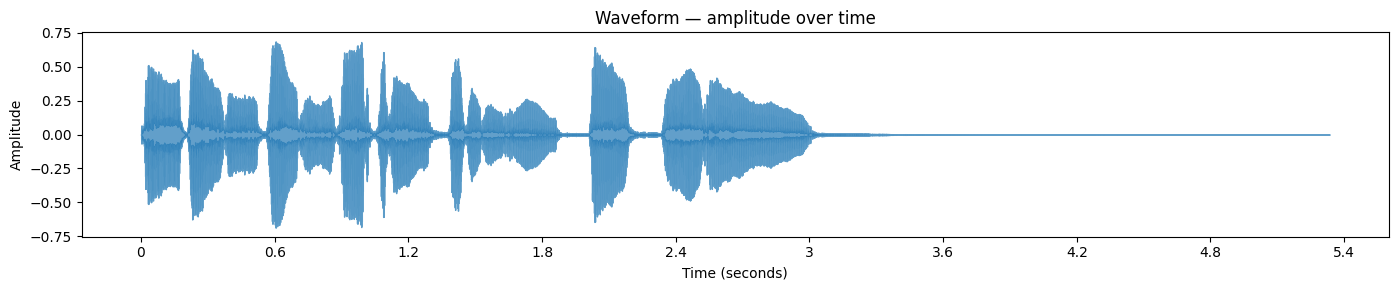

In [4]:
plt.figure(figsize=(14, 3))
librosa.display.waveshow(y, sr=sr, alpha=0.7)
plt.title('Waveform — amplitude over time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Zoom into a silence gap

Pick a time region where you can see a silence gap visually. Zoom in on it.
This gives intuition for what a 500ms gap looks like in raw amplitude — and how shallow the signal gets during natural pauses vs actual silence.

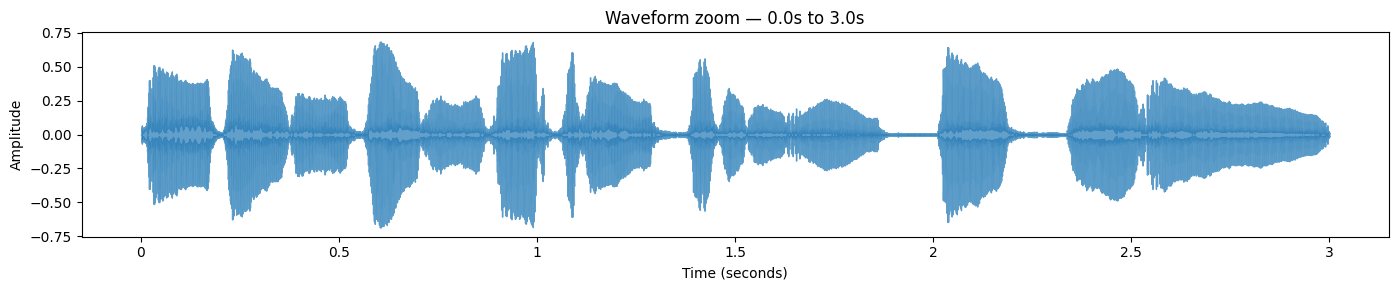

In [5]:
# Adjust start_sec and end_sec to zoom into an interesting region
start_sec = 0.0
end_sec   = 3.0

start_sample = int(start_sec * sr)
end_sample   = int(end_sec   * sr)
y_zoom = y[start_sample:end_sample]

plt.figure(figsize=(14, 3))
librosa.display.waveshow(y_zoom, sr=sr, alpha=0.7)
plt.title(f'Waveform zoom — {start_sec}s to {end_sec}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Rough energy envelope

A naive silence detector would just threshold on amplitude. Let's see what that looks like.

RMS energy per short frame — this is the raw signal an energy-based detector (Approach #1 from our approaches doc) would use.

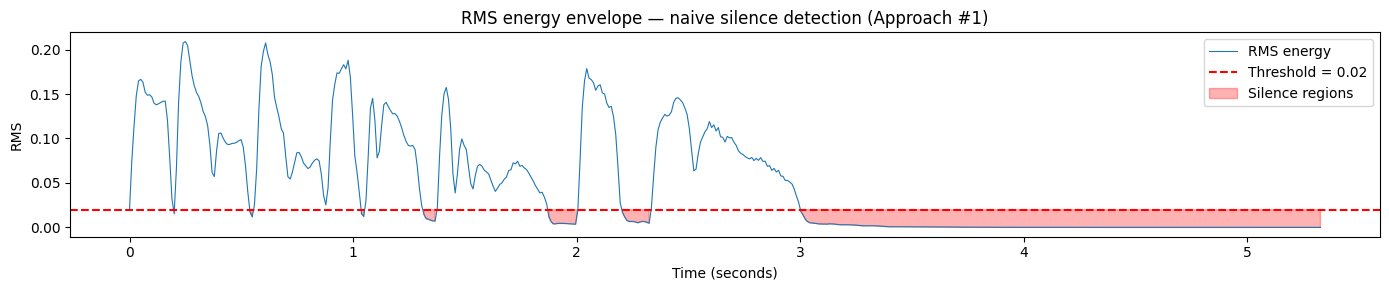

50.8% of frames below threshold — labelled as silence


In [6]:
# RMS energy in 20ms frames (hop_length = 20ms * sr)
frame_length = int(0.025 * sr)   # 25ms window
hop_length   = int(0.010 * sr)   # 10ms hop

rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
times = librosa.times_like(rms, sr=sr, hop_length=hop_length)

# Simple threshold — anything below this is "silence"
ENERGY_THRESHOLD = 0.02

plt.figure(figsize=(14, 3))
plt.plot(times, rms, label='RMS energy', linewidth=0.8)
plt.axhline(ENERGY_THRESHOLD, color='red', linestyle='--', label=f'Threshold = {ENERGY_THRESHOLD}')
plt.fill_between(times, rms, ENERGY_THRESHOLD,
                 where=(rms < ENERGY_THRESHOLD), alpha=0.3, color='red', label='Silence regions')
plt.title('RMS energy envelope — naive silence detection (Approach #1)')
plt.xlabel('Time (seconds)')
plt.ylabel('RMS')
plt.legend()
plt.tight_layout()
plt.show()

silence_fraction = (rms < ENERGY_THRESHOLD).mean()
print(f'{silence_fraction*100:.1f}% of frames below threshold — labelled as silence')